In [3]:
import xarray as xr

%config InlineBackend.figure_format='retina'
xr.set_options(display_style="text")
import os 
import pandas as pd

 Heatwaves are defined by 5 consecutives days of extreme heat.
 1) compute the extreme events for each day 
 2) if there is more than 5 --> heatwaves

In [4]:
ds = xr.open_zarr('../data/sst_daily.zarr')

In [5]:
ds = ds.sel(time=slice("1990-01-01", "2000-12-31"))


In [6]:
sst_gb = ds.sst.groupby("time.dayofyear")

In [7]:
clim_dayofyear = sst_gb.mean(dim='time')
# what is the temperature on average for each calendar year

In [8]:
# clim_dayofyear[:,250,0].plot()

In [9]:
# Compute threshold using a +/-5 day window across all years
rolling_window = 11  # 5 days before + current + 5 days after
window_radius = rolling_window // 2

sst = ds.sst
sst = sst.assign_coords(
    year=sst['time'].dt.year,
    dayofyear=sst['time'].dt.dayofyear,
)

In [10]:
# Reshape to (dayofyear, year, lat, lon)
sst_yd = (
    sst
    .set_index(time=['year', 'dayofyear'])
    .drop_duplicates('time')
    .unstack('time')
    .transpose('dayofyear', 'year', ...)
)

# Circular pad on dayofyear to support window at year boundaries
pad_left = sst_yd.isel(dayofyear=slice(-window_radius, None))
pad_right = sst_yd.isel(dayofyear=slice(0, window_radius))
sst_pad = xr.concat([pad_left, sst_yd, pad_right], dim='dayofyear')

# Rolling window over dayofyear, then compute quantile across (year, window)
threshold = (
    sst_pad
    .rolling(dayofyear=rolling_window, center=True)
    .construct('window')
    .quantile(0.9, dim=('year', 'window'))
)

# Keep the real dayofyear range (1..366)
threshold = threshold.isel(dayofyear=slice(window_radius, window_radius + sst_yd.sizes['dayofyear']))
threshold


<xarray.DataArray 'sst' (dayofyear: 366, lat: 720, lon: 1440)> Size: 3GB
dask.array<getitem, shape=(366, 720, 1440), dtype=float64, chunksize=(144, 46, 46), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * lat        (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon        (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
    quantile   float64 8B 0.9
Attributes:
    long_name:     Daily Sea Surface Temperature
    units:         degC
    valid_range:   [-3.0, 45.0]
    precision:     2.0
    dataset:       NOAA High-resolution Blended Analysis
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Individual Observations
    actual_range:  [-1.7999999523162842, 36.56999969482422]

## Detect Marine Heatwave Events (>=5 consecutive days)
This marks all days that belong to a run of exceedances with length >= MIN_DURATION.


In [17]:
import numpy as np

MIN_DURATION = 5

# Align threshold (dayofyear, lat, lon) with full time series
thresh_time = threshold.sel(dayofyear=sst['time'].dt.dayofyear)

# Boolean exceedance array over time
exceed = (sst > thresh_time)

# Mark full runs of consecutive True values with length >= MIN_DURATION

def mark_runs_1d(arr, min_len):
    arr = np.asarray(arr, dtype=bool)
    n = arr.size
    out = np.zeros(n, dtype=bool)
    if n == 0:
        return out
    diff = np.diff(arr.astype(int))
    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1
    if arr[0]:
        starts = np.r_[0, starts]
    if arr[-1]:
        ends = np.r_[ends, n]
    for s, e in zip(starts, ends):
        if (e - s) >= min_len:
            out[s:e] = True
    return out

mhw_mask = xr.apply_ufunc(
    mark_runs_1d,
    exceed,
    kwargs={"min_len": MIN_DURATION},
    input_core_dims=[["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[bool],
    dask_gufunc_kwargs={'allow_rechunk':True}
)

mhw_mask


<xarray.DataArray 'sst' (lat: 720, lon: 1440, time: 3653)> Size: 4GB
dask.array<transpose, shape=(720, 1440, 3653), dtype=bool, chunksize=(9, 9, 3653), chunktype=numpy.ndarray>
Coordinates:
  * lat        (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon        (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * time       (time) datetime64[ns] 29kB 1990-01-01 1990-01-02 ... 2000-12-31
    year       (time) int64 29kB 1990 1990 1990 1990 ... 2000 2000 2000 2000
    dayofyear  (time) int64 29kB 1 2 3 4 5 6 7 8 ... 360 361 362 363 364 365 366
    quantile   float64 8B 0.9
Attributes:
    long_name:     Daily Sea Surface Temperature
    units:         degC
    valid_range:   [-3.0, 45.0]
    precision:     2.0
    dataset:       NOAA High-resolution Blended Analysis
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Individual Observations
    actual_range:  [-1.7999999523162842, 36.56999969482422]

In [18]:
mhw_mask.shape

(720, 1440, 3653)

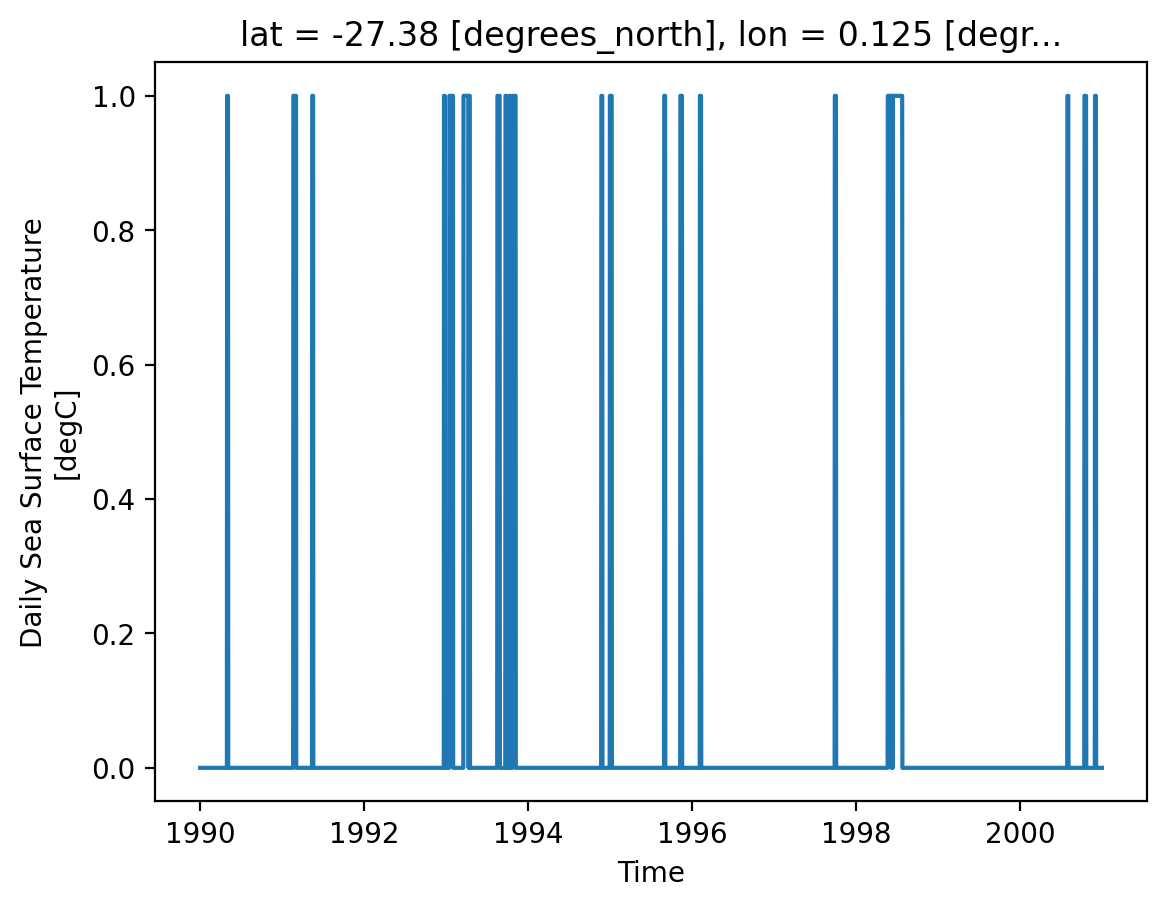

In [22]:
mhw_mask[250,0].plot()